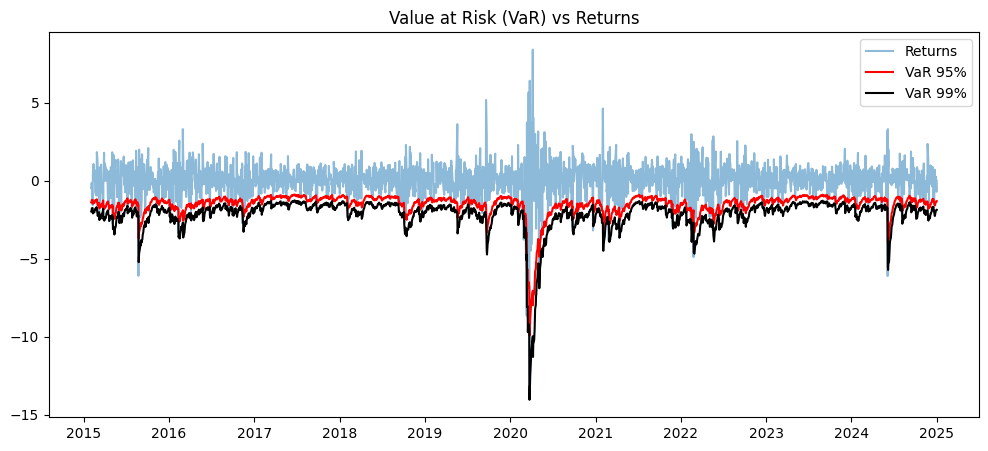


===== VaR VALIDATION =====
95% VaR Violations: 138
Expected ~121
Violation %: 0.0566

99% VaR Violations: 48
Expected ~24
Violation %: 0.0197


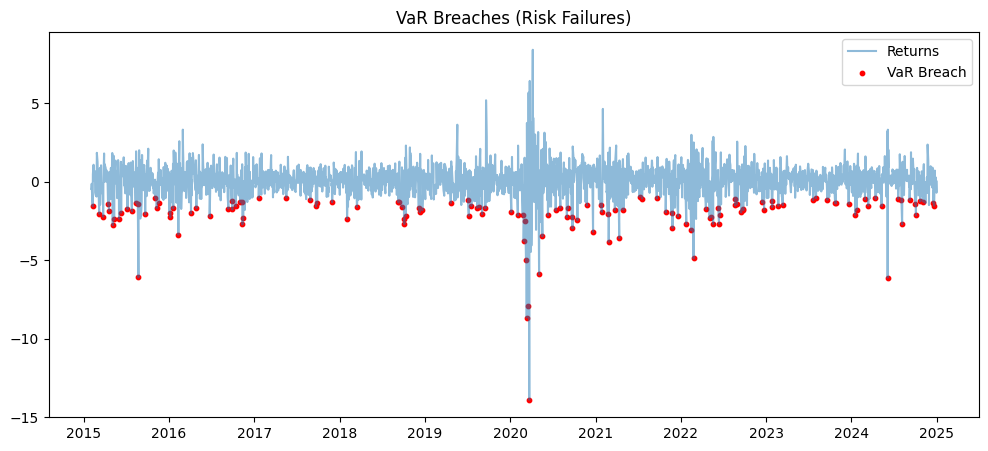

In [ ]:

import sys, os
sys.path.append(os.path.abspath(".."))

from src.data_loader import load_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = load_data("../data/nifty50_with_garch.csv")
data = data.dropna()

# Scale returns to %
data['returns_scaled'] = data['returns'] * 100


# VaR CALCULATION 


# Mean return
mu = data['returns_scaled'].mean()

# Z-scores
z_95 = -1.65
z_99 = -2.33

# VaR using GARCH volatility
data['VaR_95'] = mu + z_95 * data['garch_vol']
data['VaR_99'] = mu + z_99 * data['garch_vol']



# PLOT: VaR vs RETURNS

plt.figure(figsize=(12,5))
plt.plot(data['returns_scaled'], label='Returns', alpha=0.5)
plt.plot(data['VaR_95'], label='VaR 95%', color='red')
plt.plot(data['VaR_99'], label='VaR 99%', color='black')
plt.legend()
plt.title("Value at Risk (VaR) vs Returns")
plt.show()

# VaR VIOLATIONS (BACKTESTING)
violations_95 = (data['returns_scaled'] < data['VaR_95']).sum()
violations_99 = (data['returns_scaled'] < data['VaR_99']).sum()

total = len(data)

print("\n===== VaR VALIDATION =====")
print(f"95% VaR Violations: {violations_95}")
print(f"Expected ~{int(0.05 * total)}")
print(f"Violation %: {violations_95 / total:.4f}")

print(f"\n99% VaR Violations: {violations_99}")
print(f"Expected ~{int(0.01 * total)}")
print(f"Violation %: {violations_99 / total:.4f}")


# VaR BREACH VISUALIZATION
plt.figure(figsize=(12,5))
plt.plot(data['returns_scaled'], label='Returns', alpha=0.5)

breaches = data['returns_scaled'] < data['VaR_95']
plt.scatter(data.index[breaches], data['returns_scaled'][breaches],
            color='red', label='VaR Breach', s=10)

plt.legend()
plt.title("VaR Breaches (Risk Failures)")
plt.show()


===== CVaR RESULTS =====
CVaR 95%: -2.17
CVaR 99%: -3.07


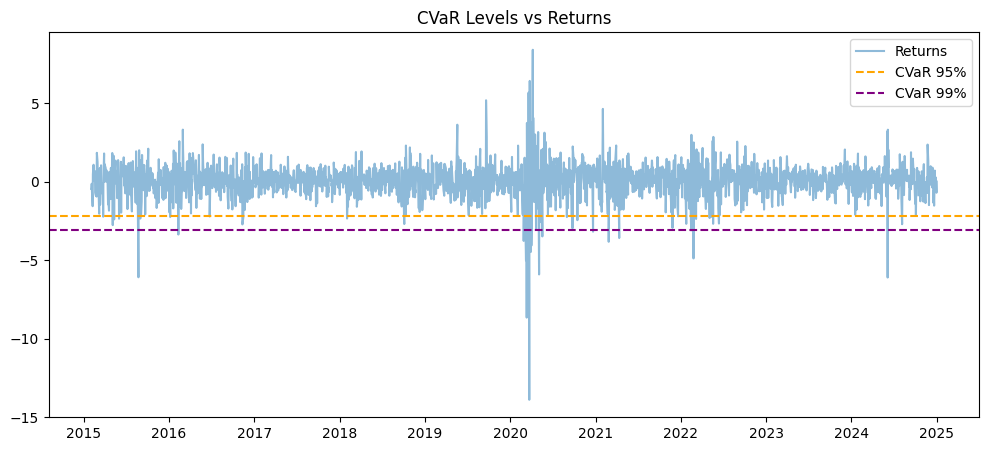

In [ ]:

# CVaR CALCULATION

cvar_95 = data.loc[data['returns_scaled'] < data['VaR_95'], 'returns_scaled'].mean()
cvar_99 = data.loc[data['returns_scaled'] < data['VaR_99'], 'returns_scaled'].mean()

print("\n===== CVaR RESULTS =====")
print(f"CVaR 95%: {cvar_95:.2f}")
print(f"CVaR 99%: {cvar_99:.2f}")


# PLOT: CVaR LEVELS
plt.figure(figsize=(12,5))
plt.plot(data['returns_scaled'], label='Returns', alpha=0.5)

plt.axhline(cvar_95, color='orange', linestyle='--', label='CVaR 95%')
plt.axhline(cvar_99, color='purple', linestyle='--', label='CVaR 99%')

plt.legend()
plt.title("CVaR Levels vs Returns")
plt.show()

In [18]:
data.to_csv("../data/nifty50_with_var_cvar.csv")

data[['returns_scaled', 'garch_vol', 'VaR_95', 'VaR_99']]\
    .to_csv("../results/var_results.csv")

data[['returns_scaled', 'VaR_95', 'VaR_99']]\
    .to_csv("../results/var_cvar_results.csv")